# Model Evaluation — 06

**Objetivo:** evaluar en profundidad el XGBoost de la fase 5 sobre el split
**de test** (datos nunca vistos por el modelo). Mientras la fase 5 reporta
métricas globales (RMSE log / USD y R²), aquí se analiza *dónde* y *cuánto*
se equivoca: residuos por observación, distribución del error relativo,
error por segmento (tipo, barrio, ambientes) y sesgo por rango de precio.

**Entrada:** `data/processed/propiedades_argenprop_curado.csv`
**Salida:** `reports/figures/` (residuos, error por segmento y sesgo por rango, PNG)

## Configuración

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# `metricas_por_segmento` evalúa R² por grupo; con segmentos de 1 observación
# (p. ej. cochera u oficina) sklearn emite UndefinedMetricWarning (esperado).
warnings.filterwarnings("ignore", message=".*less than two samples.*")

# Bootstrap para importar `real_estate` (layout src/) sin instalar el paquete.
SRC_DIR = Path.cwd().parent / "src"
if not SRC_DIR.exists():
    SRC_DIR = Path.cwd() / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from real_estate.evaluacion import (  # noqa: E402
    bias_por_rango_precio,
    grafico_error_segmento,
    grafico_residuos,
    grafico_sesgo_rango,
    guardar_figuras,
    metricas_detalladas,
    metricas_por_segmento,
    resumen_errores,
    tabla_residuos,
)
from real_estate.features import pipeline as pl  # noqa: E402
from real_estate.features import transformations as tr  # noqa: E402
from real_estate.models import entrenamiento as en  # noqa: E402

RUTA_CURADO = Path("../data/processed/propiedades_argenprop_curado.csv")
RUTA_FIGURAS = Path("../reports/figures")

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)

## 1. Carga y split train / val / test

Igual que en los notebooks 04 y 05: preprocesamiento ajustado **solo sobre
train** y reaplicado a val/test (sin fuga). El análisis profundo se hace
sobre test; val se usa para comparar el XGBoost contra el baseline.

In [2]:
df_curado = pd.read_csv(RUTA_CURADO, low_memory=False)
print(f"Curado: {df_curado.shape[0]:,} filas x {df_curado.shape[1]} columnas")

matriz = tr.crear_target_log(tr.seleccionar_columnas(df_curado))
train, val, test = pl.dividir_train_val_test(matriz, random_state=42)

print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")

Curado: 2,005 filas x 32 columnas
Descartadas 6 filas con precio inválido (< 1,000 USD).
Train: 1,599 | Val: 200 | Test: 200


## 2. Preprocesamiento ajustado solo sobre train

In [3]:
ajustes = en.ajustar_preprocesamiento(train)

train_proc = en.aplicar_preprocesamiento(train, ajustes)
val_proc = en.aplicar_preprocesamiento(val, ajustes)
test_proc = en.aplicar_preprocesamiento(test, ajustes)

print(
    f"NaN totales tras preprocesar: train {int(train_proc.isna().sum().sum())} | "
    f"val {int(val_proc.isna().sum().sum())} | test {int(test_proc.isna().sum().sum())}"
)

NaN totales tras preprocesar: train 0 | val 0 | test 0


## 3. Features y target

In [4]:
X_train, y_train = en.separar_features_target(train_proc)
X_val, y_val = en.separar_features_target(val_proc)
X_test, y_test = en.separar_features_target(test_proc)

print(f"Features ({X_train.shape[1]}): {list(X_train.columns)}")
print("Target: log_precio_usd")

Features (14): ['superficie_cubierta', 'ambientes', 'dormitorios', 'banos', 'antiguedad', 'expensas_usd', 'expensas_informado', 'superficie_cubierta_informado', 'ambientes_informado', 'dormitorios_informado', 'banos_informado', 'antiguedad_informado', 'barrio_ordinal', 'tipo_propiedad_ordinal']
Target: log_precio_usd


## 4. Entrenamiento (baseline + XGBoost)

Se reentrena el pipeline completo sobre train (mismos hiperparámetros que en
el notebook 04) para disponer de ambos modelos en memoria con su codificación
exacta.

In [5]:
resultado = en.entrenar_y_evaluar(train, val, test, random_state=42)

pred_baseline_val = resultado.modelo_baseline.predict(X_val)
pred_xgb_val = resultado.modelo_xgboost.predict(X_val)
pred_xgb_test = resultado.modelo_xgboost.predict(X_test)

en.mostrar_metricas("baseline (val)", resultado.metricas_baseline_val)
en.mostrar_metricas("xgboost (val)", resultado.metricas_xgboost_val)
en.mostrar_metricas("xgboost (test)", resultado.metricas_xgboost_test)


ENTRENAMIENTO Y EVALUACIÓN

Preprocesamiento ajustado solo sobre train (sin fuga): 2 categóricas con orden ordinal, 6 numéricas con imputación por mediana.

Split: train 1,599 | val 200 | test 200
Features: 14 | Target: log_precio_usd



Métricas sobre VALIDACIÓN:
  baseline     | RMSE log: 0.6423 | RMSE USD:      185,135 | R²: -0.0025
  xgboost      | RMSE log: 0.2718 | RMSE USD:      112,963 | R²: 0.8205

Mejor modelo en val: xgboost

Métricas de XGBoost sobre TEST (modelo final):
  xgboost      | RMSE log: 0.3040 | RMSE USD:       87,244 | R²: 0.7830
  baseline (val) | RMSE log: 0.6423 | RMSE USD:      185,135 | R²: -0.0025
  xgboost (val) | RMSE log: 0.2718 | RMSE USD:      112,963 | R²: 0.8205
  xgboost (test) | RMSE log: 0.3040 | RMSE USD:       87,244 | R²: 0.7830


## 5. Métricas detalladas

Amplían las métricas de la fase 5: MAE / MedAE / MAPE en USD y RMSE log,
todas deshaciendo el log cuando corresponda. El baseline (mediana) sirve de
referencia: cualquier modelo útil debe superarlo claramente.

In [6]:
tabla_metricas = pd.DataFrame(
    {
        "baseline (val)": metricas_detalladas(y_val, pred_baseline_val),
        "xgboost (val)": metricas_detalladas(y_val, pred_xgb_val),
        "xgboost (test)": metricas_detalladas(y_test, pred_xgb_test),
    }
)
print(tabla_metricas.round(2).to_string())

           baseline (val)  xgboost (val)  xgboost (test)
rmse_log             0.64           0.27            0.30
rmse_usd        185135.04      112963.01        87244.13
mae_usd          99215.60       48911.36        44050.41
medae_usd        63000.00       23357.89        21485.69
mape_usd            52.77          21.16           21.71
r2                  -0.00           0.82            0.78


## 6. Tabla de residuos y resumen (test)

`tabla_residuos` arma, por observación del test: precio real y predicho
(USD), `residuo_log` (pred - real en log; positivo = sobreestima) y
`error_relativo` (`exp(residuo_log) - 1`). El resumen condensa la
distribución del error relativo **absoluto** en %. Este panel es el insumo
para los gráficos de la sección 7.

In [7]:
tabla = tabla_residuos(y_test, pred_xgb_test)
print(tabla.head(10).round(2).to_string())

resumen = resumen_errores(tabla)
print("\nResumen de errores (test):")
print(resumen.round(3).to_string())

   precio_real_usd  precio_pred_usd  residuo_log  residuo_usd  error_relativo
0          78200.0         64058.96        -0.20    -14141.04           -0.18
1          38000.0         54227.88         0.36     16227.88            0.43
2          89900.0         74488.43        -0.19    -15411.57           -0.17
3         225000.0        215897.58        -0.04     -9102.42           -0.04
4         117000.0         96395.74        -0.19    -20604.26           -0.18
5          67900.0         89595.38         0.28     21695.38            0.32
6          99000.0        106895.81         0.08      7895.81            0.08
7         160000.0        172074.89         0.07     12074.89            0.08
8          75000.0         83860.60         0.11      8860.60            0.12
9         265000.0        324451.03         0.20     59451.03            0.22

Resumen de errores (test):
n                    200.000
sesgo_log_medio        0.008
sesgo_pct_medio        5.021
error_pct_mediana     17.73

## 7. Residuos en gráficos

Izquierda: histograma del error relativo (%) — el pico debe centrarse en 0
(sin sesgo sistemático) y la cola derecha muestra las sobreestimaciones
grandes. Derecha: precio predicho vs. real con la diagonal `y = x`; los
puntos sobre la recta son predicciones exactas.

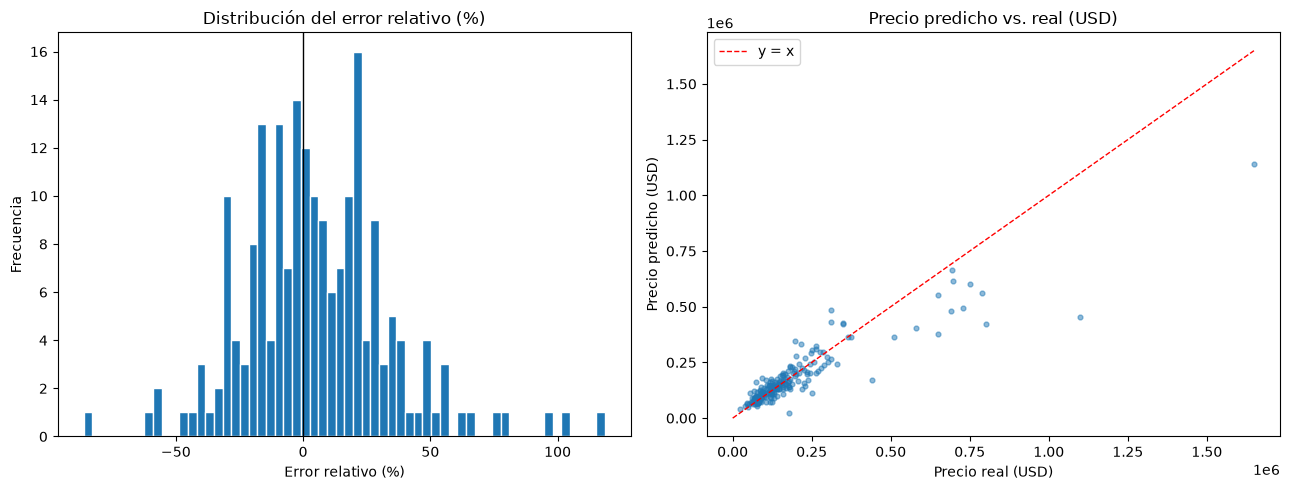

In [8]:
fig_residuos = grafico_residuos(tabla)
plt.show()

## 8. Error por segmento

Se agrupa el test por columnas **originales** (sin codificar) y se computan
las métricas por grupo, ordenadas por número de observaciones. Esto detecta
en qué tipos de propiedad, barrios o tamaños (ambientes) el modelo falla
más, con su `n` para no sobreinterpretar segmentos chicos.


### tipo_propiedad (7 segmentos)
                n  rmse_log   rmse_usd  mape_usd
segmento                                        
departamento  176      0.25   62531.48     20.12
ph             11      0.29   41120.53     25.34
casa            6      0.39  199394.01     28.20
terreno         4      0.55  346780.80     45.51
cochera         1      1.98  154309.05     86.21
oficina         1      0.81  139235.26     55.69
local           1      0.34  229655.98     29.07

### barrio (36 segmentos)
                n  rmse_log   rmse_usd  mape_usd
segmento                                        
Palermo        20      0.25   61777.39     21.80
Belgrano       19      0.18   77446.20     14.00
Caballito      19      0.20   29289.97     17.95
Villa Urquiza  16      0.53   63447.66     19.58
Villa Devoto   12      0.34  146234.22     27.93
Balvanera      12      0.27   25650.82     21.11
Almagro         9      0.36  216298.97     23.38
Barrio Norte    9      0.29   39398.21     23.73
Nuñez   

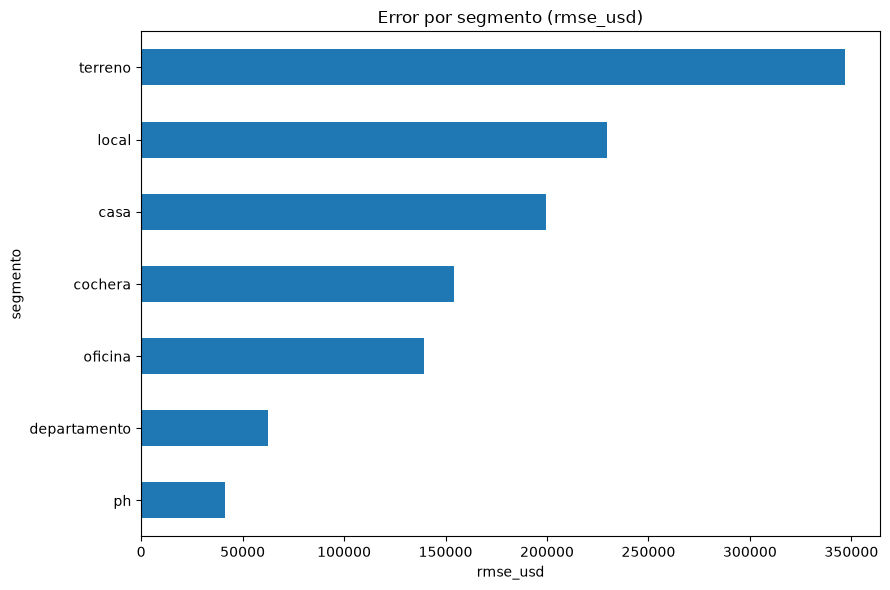

In [9]:
for nombre, valores in [
    ("tipo_propiedad", test["tipo_propiedad"]),
    ("barrio", test["barrio"]),
    ("ambientes", test["ambientes"]),
]:
    por_segmento = metricas_por_segmento(valores, y_test, pred_xgb_test)
    print(f"\n### {nombre} ({len(por_segmento)} segmentos)")
    print(por_segmento[["n", "rmse_log", "rmse_usd", "mape_usd"]].round(2).head(10).to_string())

seg_tipo = metricas_por_segmento(test["tipo_propiedad"], y_test, pred_xgb_test)

fig_error_segmento = grafico_error_segmento(seg_tipo, metrica="rmse_usd")
plt.show()

## 9. Sesgo por rango de precio

`bias_por_rango_precio` parte el test en bandas con el mismo número de
observaciones (`pd.qcut`) y mide el sesgo promedio por banda: positivo =
sobreestima, negativo = subestima. Revela patrones como "sobreestimar lo
barato y subestimar lo caro", típicos de regresores con error proporcional.

                        n  precio_min_usd  precio_medio_usd  precio_max_usd  sesgo_log  sesgo_pct  rmse_log
rango_precio                                                                                               
(23999.999, 85400.0]   40         24000.0          68620.00         85000.0       0.16      17.17      0.29
(85400.0, 120000.0]    41         85500.0         104464.17        120000.0       0.11      11.92      0.26
(120000.0, 160000.0]   42        123000.0         140847.36        160000.0       0.00       0.05      0.18
(160000.0, 235000.0]   38        165000.0         194303.58        235000.0      -0.07      -6.72      0.40
(235000.0, 1649000.0]  39        237000.0         460437.95       1649000.0      -0.17     -15.83      0.36


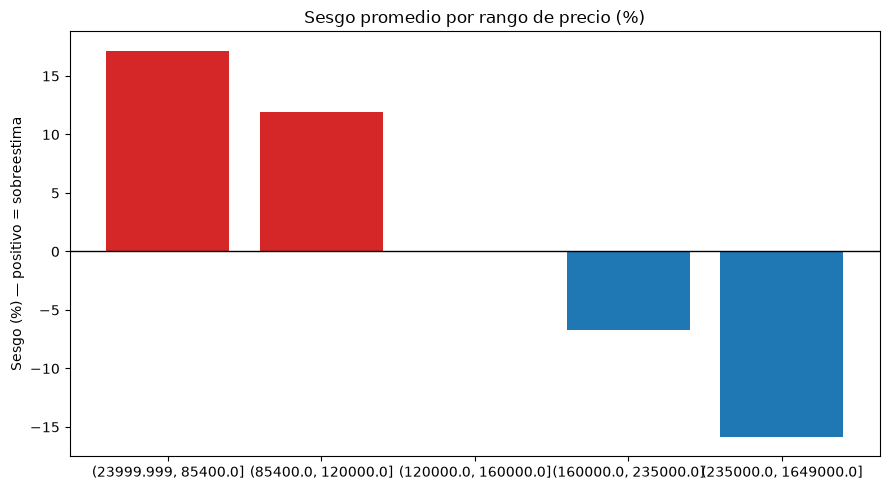

In [10]:
bias = bias_por_rango_precio(tabla["precio_real_usd"], tabla["residuo_log"], n_bandas=5)
print(bias.round(2).to_string())

fig_sesgo_rango = grafico_sesgo_rango(bias)
plt.show()

## 10. Guardar figuras

Se persisten como PNG en `reports/figures/` (carpeta gitignored: se
regeneran con este notebook; solo se versiona `.gitkeep`).

In [11]:
rutas = guardar_figuras(
    {
        "evaluacion_residuos": fig_residuos,
        "evaluacion_error_segmento": fig_error_segmento,
        "evaluacion_sesgo_rango": fig_sesgo_rango,
    },
    RUTA_FIGURAS,
)
for ruta in rutas:
    print(f"Guardado: {ruta} ({ruta.stat().st_size:,} bytes)")

Guardado: ..\reports\figures\evaluacion_residuos.png (82,590 bytes)
Guardado: ..\reports\figures\evaluacion_error_segmento.png (32,480 bytes)
Guardado: ..\reports\figures\evaluacion_sesgo_rango.png (35,410 bytes)


## 11. Conclusiones

In [12]:
met_test = metricas_detalladas(y_test, pred_xgb_test)

print("Evaluación profunda (fase 8) — XGBoost sobre test:")
print(
    f"  RMSE log {met_test['rmse_log']:.4f} | RMSE USD ${met_test['rmse_usd']:,.0f} | R² {met_test['r2']:.3f}"
)
print(f"  sesgo medio: {resumen['sesgo_pct_medio']:+.2f} % (positivo = sobreestima)")
print(
    f"  error relativo: mediana {resumen['error_pct_mediana']:.2f} % | p90 {resumen['error_pct_p90']:.2f} %"
)
print(f"  segmentos por tipo: {seg_tipo[['n', 'rmse_usd']].round(0).to_dict('index')}")
print(f"  figuras guardadas en {RUTA_FIGURAS}")
print("\nSiguiente: con entrenamiento (5), tracking (6), explicabilidad (7) y evaluación (8),")
print("el pipeline queda listo para empaquetar (Docker) y servir (deployment).")

Evaluación profunda (fase 8) — XGBoost sobre test:
  RMSE log 0.3040 | RMSE USD $87,244 | R² 0.783
  sesgo medio: +5.02 % (positivo = sobreestima)
  error relativo: mediana 17.73 % | p90 43.96 %
  segmentos por tipo: {'departamento': {'n': 176, 'rmse_usd': 62531.0}, 'ph': {'n': 11, 'rmse_usd': 41121.0}, 'casa': {'n': 6, 'rmse_usd': 199394.0}, 'terreno': {'n': 4, 'rmse_usd': 346781.0}, 'cochera': {'n': 1, 'rmse_usd': 154309.0}, 'oficina': {'n': 1, 'rmse_usd': 139235.0}, 'local': {'n': 1, 'rmse_usd': 229656.0}}
  figuras guardadas en ..\reports\figures

Siguiente: con entrenamiento (5), tracking (6), explicabilidad (7) y evaluación (8),
el pipeline queda listo para empaquetar (Docker) y servir (deployment).
